In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [2]:
sales = pd.read_csv("D:/Data Analysis/Tamweely Train/Brazilian E-Commerce Dataset/data/Sales_Master_Clean.csv")

sales.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,City,State,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,Revenue,freight_value,payment_sequential,payment_type,payment_installments,Payment,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,Delivery_Days,Order_Month,Order_Year,quantity,Total_Revenue,Profit,Delivery_Status,Customer_Type
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,1,credit_card,2,146.87,moveis escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,8.0,5,2017,1,146.87,29.374,Delayed,New
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,1,credit_card,8,335.48,utilidades domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,16.0,1,2018,1,335.48,67.096,Delayed,New
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,1,credit_card,7,157.73,moveis escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,26.0,5,2018,1,157.73,31.546,Delayed,New
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,1,credit_card,1,173.30,moveis escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,14.0,3,2018,1,173.30,34.660,Delayed,New
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,1,credit_card,8,252.25,casa conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,11.0,7,2018,1,252.25,50.450,Delayed,New


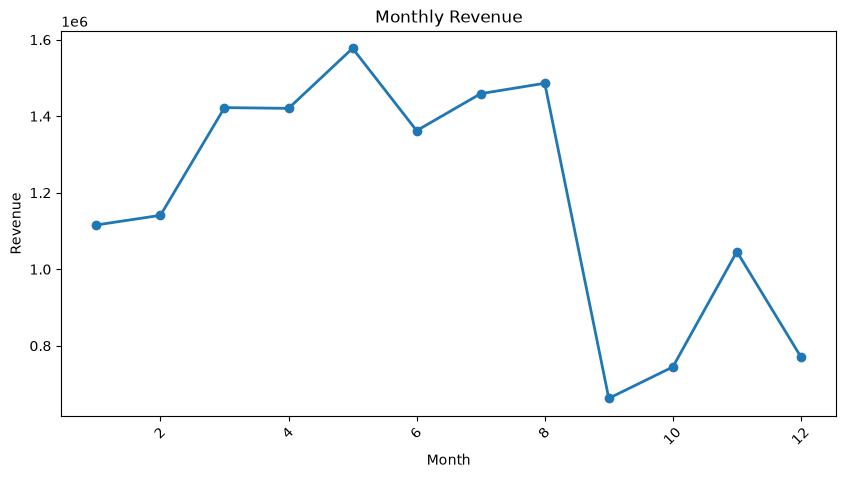

In [3]:
monthly_revenue = (
    sales.groupby("Order_Month")["Revenue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

It mirrors the orders drop almost exactly, confirming the September drop is operational/systemic rather than just seasonal — especially since it recovers within a couple months.

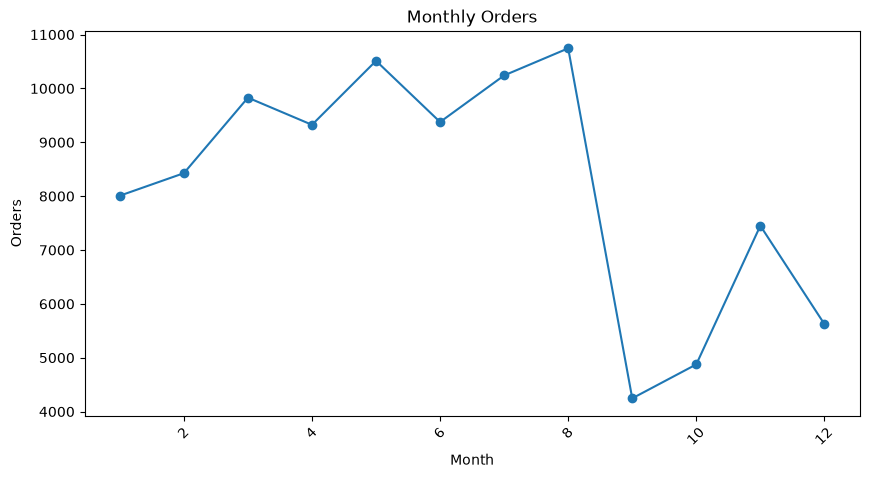

In [4]:
monthly_orders = (
    sales.groupby("Order_Month")["order_id"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

There's a sharp drop in month 9 (from ~10.7k to ~4.3k). This doesn't look like normal seasonality — it needs immediate investigation (possibly missing data or a real operational disruption).

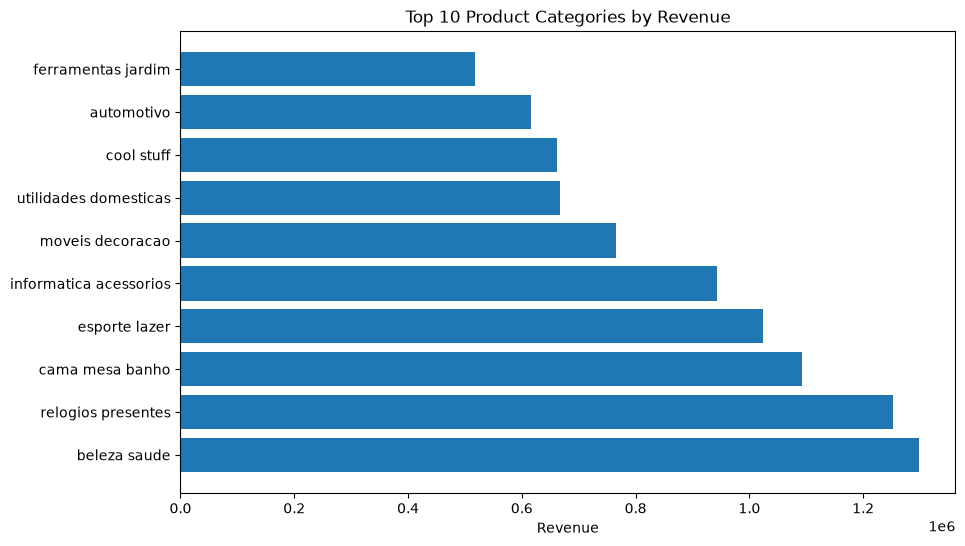

In [5]:
top_categories = (
    sales.groupby("product_category_name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_categories.index,
    top_categories.values
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")

plt.show()

beleza_saude and relogios_presentes lead, but the gap between top categories isn't large. That's an opportunity for cross-selling across categories rather than over-relying on one.

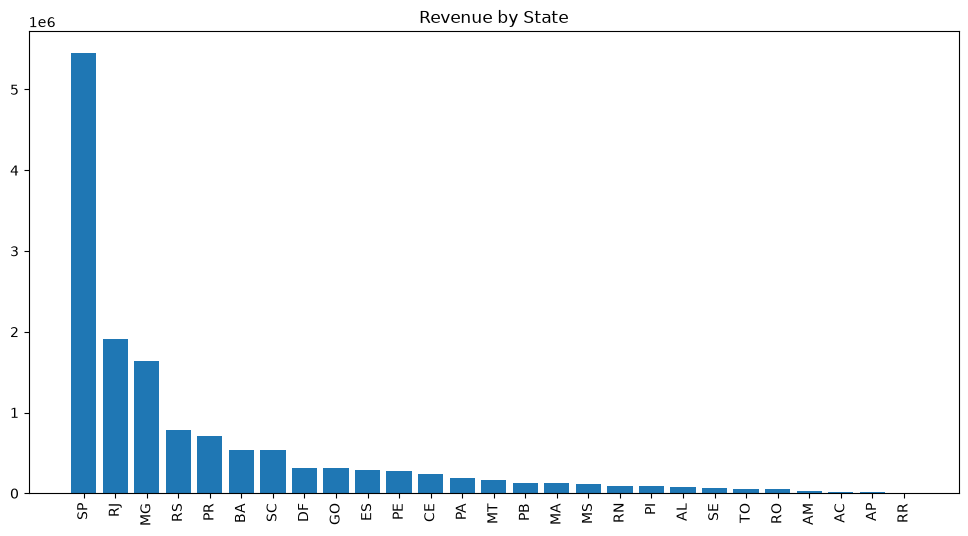

In [7]:
state_revenue = (
    sales.groupby("State")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    state_revenue.index,
    state_revenue.values
)

plt.title("Revenue by State")

plt.xticks(rotation=90)

plt.show()

SP alone generates roughly as much revenue as most other states combined. This is heavy geographic concentration risk; an economic slowdown in SP would hit total revenue directly.

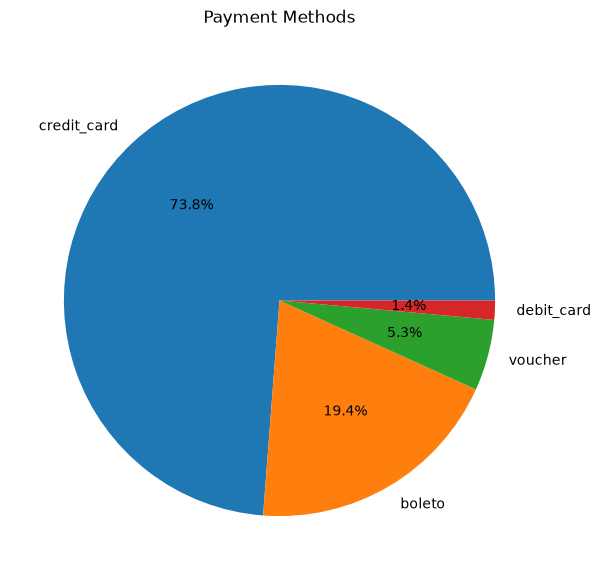

In [8]:
payment = sales["payment_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    payment.values,
    labels=payment.index,
    autopct="%1.1f%%"
)

plt.title("Payment Methods")

plt.show()

73.8% of transactions go through credit card. Any disruption to the credit card payment gateway would affect the majority of revenue — a clear single-point-of-failure dependency.

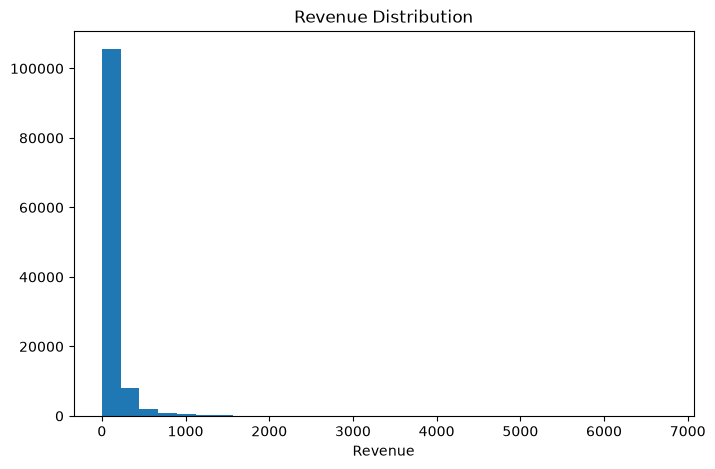

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    sales["Revenue"],
    bins=30
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")

plt.show()

Same long-tail pattern: most orders are low value, with a few high-value outliers. Average order value isn't representative here — median or customer segmentation (like RFM) would give a truer picture.

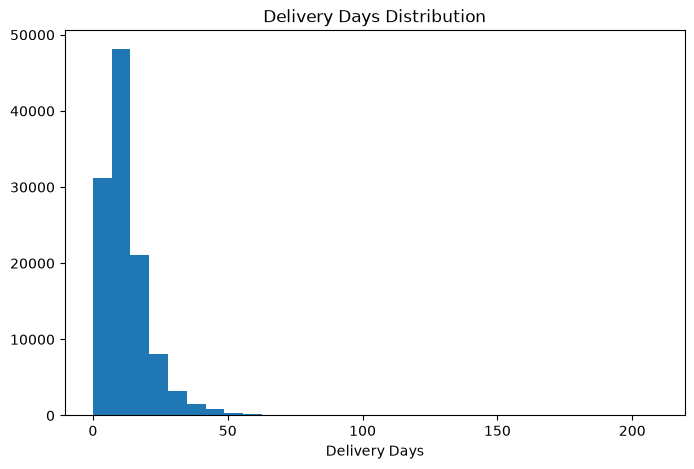

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    sales["Delivery_Days"],
    bins=30
)

plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")

plt.show()

Most orders deliver in under 20 days, but there's a tail stretching to 100–200 days. Those extreme cases deserve separate investigation (likely data errors or genuine logistics failures hurting customer satisfaction).

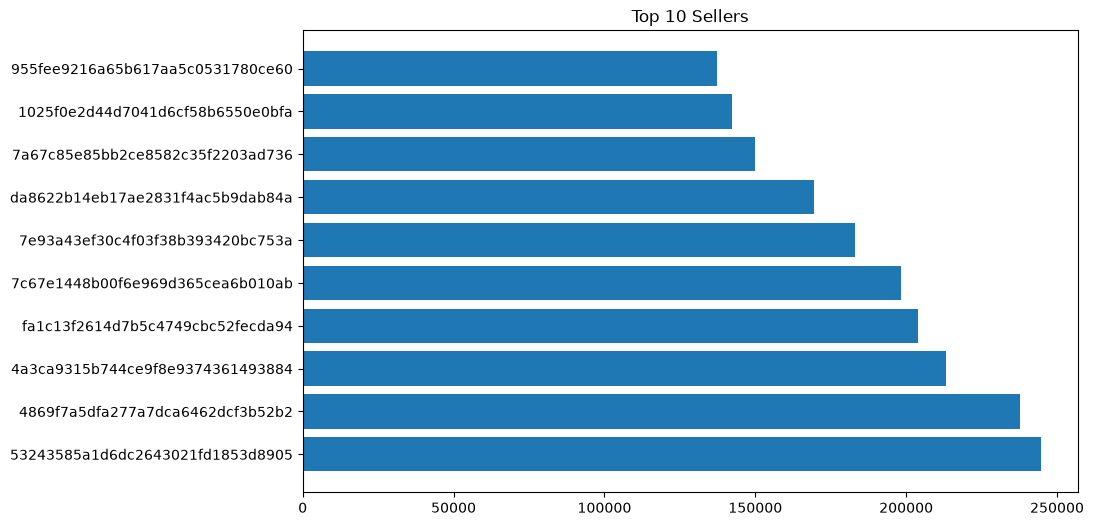

In [11]:
top_sellers = (
    sales.groupby("seller_id")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_sellers.index,
    top_sellers.values
)

plt.title("Top 10 Sellers")

plt.show()

Opposite story here. The top seller does almost double the revenue of the 10th-ranked seller (250k vs 140k). This signals real seller concentration risk — losing or having issues with the top seller would meaningfully hurt total revenue.

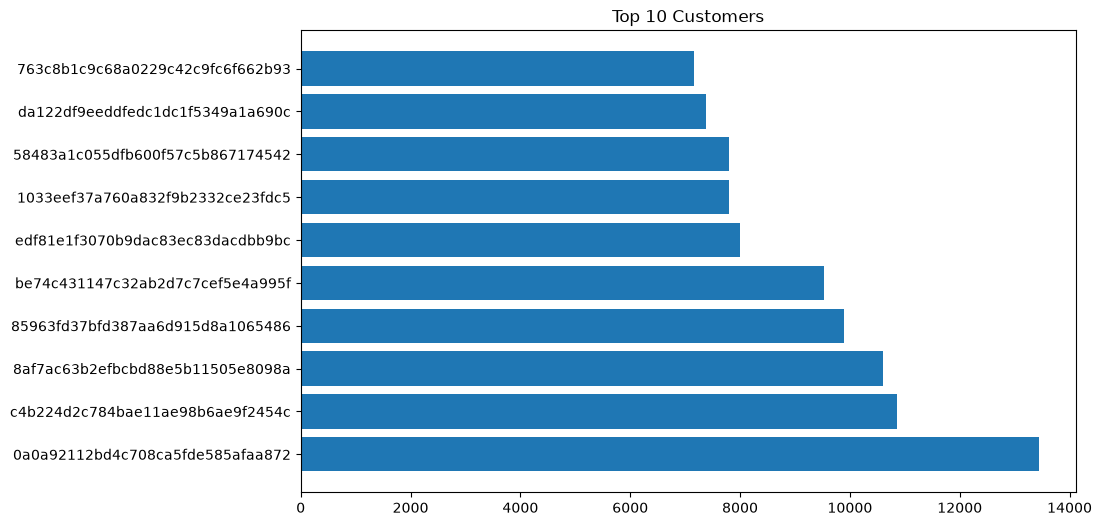

In [12]:
top_customers = (
    sales.groupby("customer_unique_id")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_customers.index,
    top_customers.values
)

plt.title("Top 10 Customers")

plt.show()

The gap between the top customer (~13.5k) and the 10th (~7k) isn't huge, meaning no single customer dominates. Low customer concentration risk — that's healthy for business stability.

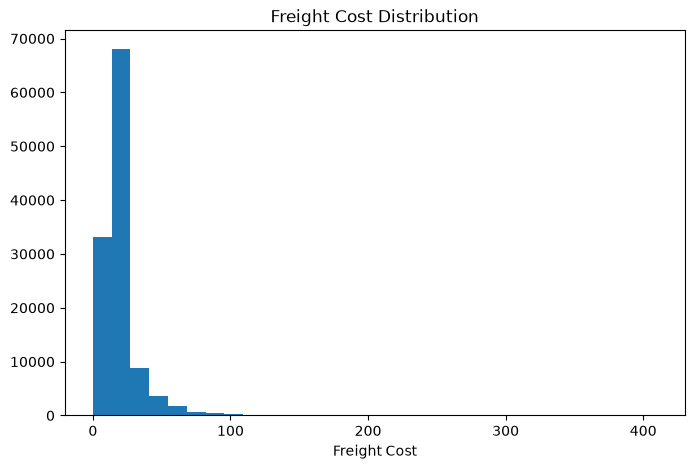

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    sales["freight_value"],
    bins=30
)

plt.title("Freight Cost Distribution")
plt.xlabel("Freight Cost")

plt.show()

Most shipments cost under 30, but there's a long tail stretching to 100+. This means averages will be misleading; you'd want outlier handling or tiered freight pricing analysis instead of a simple mean